In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import json
import EvaluationTools as et

In [2]:
qs_dict=json.load(open('/Users/rm026/Documents/code/reviewpyper/extraction_questions.json'))['hbs_seizure']
# for long_q, short_q in qs[set].items():
    # qs_expls.update({long_q: short_q, f"EXPLANATION: {long_q}":f"explanation: {short_q}"})

qs=['seizure']

ai=pd.read_csv('/Users/rm026/Documents/hbs_study_patient_notes/jan_2026_reviewpyper_results/hbs_seizure_reviewpyper_2-2-2026/master_list_seizure_checked.csv')
# ai=ai[ai.columns.drop(list(ai.filter(regex='explanation')))]
# ai.rename(columns=qs_dict, inplace=True)
# ai=ai[['MRN']+qs]


gt=pd.read_csv('/Users/rm026/Documents/hbs_study_patient_notes/llm_subset_n344_seizure_col_only_updated.csv')
gt['MRN']=gt['MRN'].astype(int)
gt=gt[['MRN', 'seizures_manual','history_of_seizures_before_stroke_manual', 'post-stroke seizures_manual','acute_seizure_manual','late_seizure_manual']]
gt.columns=['MRN']+list(qs_dict.values())+['late seizure_gt']
gt=gt[gt['seizure'].isin([0,1,'0','1',0.0,1.0])]
gt=gt.fillna(0)
gt=gt.drop_duplicates(subset='MRN',keep='first')
# gt[gt.duplicated(subset='MRN', keep=False)]

In [3]:

for col in gt.columns:
    if col=='MRN':
        continue
    else:
        # print(col)
        gt[col]=gt[col].astype(int)+1

merged=pd.merge(ai,gt,on='MRN',suffixes=('_ai','_gt'), how='inner')
print(len(ai),len(gt), len(merged))
merged


339 331 329


,MRN,seizure_ai,explanation: seizure,seizure_gt,pre-stroke seizure,post-stroke seizure,acute seizure,late seizure_gt
0,18397,0.0,NaN,1,1,1,1,1
1,20900,0.0,NaN,1,1,1,1,1
2,41323,0.0,NaN,1,1,1,1,1
3,41537,0.0,NaN,1,1,1,1,1
4,70571,0.0,NaN,1,1,1,1,1
...,...,...,...,...,...,...,...,...
324,5066285,0.0,NaN,1,1,1,1,1
325,5079494,2.0,"2: The 8/31/2012 discharge summary lists ""seiz...",2,1,2,1,2
326,5082158,2.0,"2: The text states ""Reason for Admission: seiz...",2,1,2,1,2
327,5093845,2.0,"2: The principal diagnosis is ""Partial seizure...",2,1,2,1,2


In [4]:
conf_matrix=np.array([[0,0,0],
                    [0,0,0],
                    [0,0,0]])
confs={}
for q in qs:
    confs[q]=et.confusion_matrix(merged[q+'_gt'],merged[q+'_ai'])

conf_matrix=sum(confs.values())
conf_df=pd.DataFrame(conf_matrix,columns=['Predict yes','Predict no','Predict unknown',],index=['Truth yes','Truth no','Truth unknown'])
print(conf_df)
print(et.combine_no_and_unknown(conf_matrix))
print(et.accuracy(et.combine_no_and_unknown(conf_matrix)))

               Predict yes  Predict no  Predict unknown
Truth yes              101           0                7
Truth no                 9           2              210
Truth unknown            0           0                0
[[101   7]
 [  9 212]]
0.9513677811550152


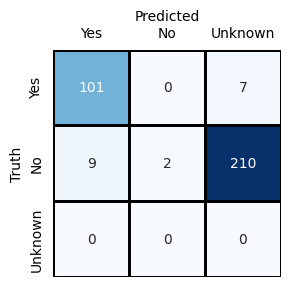

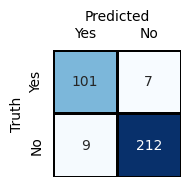

In [5]:
et.plot_conf_matrix(conf_matrix, 
                 filename=f'/Users/rm026/Documents/hbs_study_patient_notes/jan_2026_reviewpyper_results/confidence_matrix.svg')
et.plot_conf_matrix(et.combine_no_and_unknown(conf_matrix), 
                 figsz=(2,2),
                 filename=f'/Users/rm026/Documents/hbs_study_patient_notes/jan_2026_reviewpyper_results/confidence_matrix_combine_no_unknown.svg')

In [6]:
resultsdf=et.statistical_df({q:et.combine_no_and_unknown(mat) for q,mat in confs.items()})
resultsdf=resultsdf.round(3)
resultsdf


,question,accuracy,specificity,sensitivity,positive predictive power,negative predictive power
0,seizure,0.951,0.959,0.935,0.918,0.968
1,overall,0.951,0.959,0.935,0.918,0.968


/Users/rm026/Documents/code/ReviewPyper/dev_tools/EvaluationTools.py:200: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  bar1.set_xticklabels(xlabels)


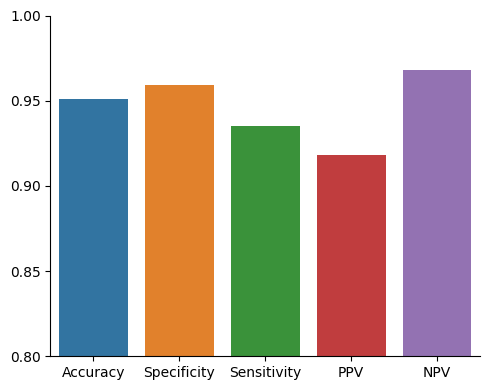

In [7]:
et.barplot(resultsdf.iloc[0].values.tolist()[1:],
        ['Accuracy','Specificity','Sensitivity','PPV','NPV'],
        filename=f'/Users/rm026/Documents/hbs_study_patient_notes/jan_2026_reviewpyper_results/eval_scores_barplot.svg',
        figsz=(5,4), ylims=(.8,1))

In [8]:
confs_ignore_unk={q:et.ignore_unknown(matrix) for q,matrix in confs.items()}
ignore_unk=et.statistical_df(confs_ignore_unk)

confs_combo_unk={q:et.combine_no_and_unknown(matrix) for q, matrix in confs.items()}
combo_unk=et.statistical_df(confs_combo_unk)

In [9]:
fp=merged[(merged['seizure_ai']==2) & (merged['seizure_gt']!=2)]
fp

,MRN,seizure_ai,explanation: seizure,seizure_gt,pre-stroke seizure,post-stroke seizure,acute seizure,late seizure_gt
25,649668,2.0,"2: The text lists ""seizure disorder"" as an ass...",1,1,1,1,1
134,2591501,2.0,"2: The text lists ""Associated Dx: Seizure"" in ...",1,1,1,1,1
165,3686478,2.0,"2: The text states ""She was noted to have a br...",1,1,1,1,1
169,3834550,2.0,"2: The patient had ""whole body shaking"" events...",1,1,1,1,1
171,3911149,2.0,"2: The EMR states ""she had a focal seizure or ...",1,1,1,1,1
217,4733189,2.0,2: The principal diagnosis for one admission i...,1,1,1,1,1
233,4739666,2.0,"2: The text states, ""he had an episode of conf...",1,1,1,1,1
267,4757607,2.0,"2: On 08/26/09, nursing staff suspected seizur...",1,1,1,1,1
286,4879349,2.0,"2: The text in the June 17, 2010 summary inclu...",1,1,1,1,1
